In [1]:
from pathlib import Path
import sys
import os

# Add parent directory to Python path
project_root = Path("/home/nbyrnes/code/random-matrix/")  # <-- adjust this
sys.path.insert(0, str(project_root))

import pickle
import time
import warnings
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import scipy.sparse
import shapely
import tqdm
import quadpy
import warnings
from random_matrix.amplitude_matrix import (
    isotropic_sphere,
    scattering_geometry,
)
from random_matrix.input_statistics import density_function, density_integrals
from random_matrix.input_statistics.density_function import (
    DeltaDensityFactor,
    DensityFunction,
    DensityFunctionTerm,
    RegularDensityFactor,
)
from random_matrix.input_statistics.index_finder import IndexFinder
from random_matrix.input_statistics.input_statistics_manager import (
    InputStatisticsManager,
)
from random_matrix.input_statistics.integration_task import (
    IntegrationTaskPreparer,
    IntegrationTaskConfig,
)
from random_matrix.input_statistics.medium_parameters import MediumParameters
from random_matrix.input_statistics.medium_statistics import (
    MediumStatistics,
    ParticleStatistics,
)
from random_matrix.input_statistics.matrix_pool_manager import MatrixPoolManager
from random_matrix.modes import mode_grid, mode_grid_factory
from random_matrix.utils import (
    array_utils,
    function_utils,
    geometry_utils,
    integration_utils,
    matrix_utils,
    special_functions,
)
from random_matrix.scattering_matrix import sampler
import cupy as cp
import math
from tqdm import tqdm
from shapely.geometry import Point, Polygon
from scipy.signal import czt
from random_matrix.utils import geometry_utils as sg


In [2]:
# Some useful functions


def get_e_theta_phi(
    k_x: np.ndarray | cp.ndarray,
    k_y: np.ndarray | cp.ndarray,
    k_z: np.ndarray | cp.ndarray,
) -> tuple[np.ndarray | cp.ndarray, np.ndarray | cp.ndarray]:
    """Get the theta and phi spherical polar basis vectors associated with
    a plane wave with given wavevector. The wavevector is assumed to be
    normalized."""
    xp = sg.array_utils.get_module(k_x)

    mod_kappa = xp.sqrt((k_x**2 + k_y**2))

    # Find indices where k is parallel to z
    bad_indices = xp.where(xp.isclose(mod_kappa, 0.0))
    num_bad_indices = len(bad_indices[0])

    # Do the cross product and normalize (e_phi = z cross k)
    e_phi = xp.empty((*k_x.shape, 3))
    e_phi[..., 0] = k_y
    e_phi[..., 1] = -k_x
    e_phi[..., 2] = 0.0
    e_phi /= mod_kappa[..., xp.newaxis]
    e_phi[bad_indices] = xp.column_stack(
        (
            xp.zeros(num_bad_indices),
            k_z[bad_indices],
            xp.zeros(num_bad_indices),
        )
    )

    # e_theta = e_phi cross k
    e_theta = xp.empty((*k_x.shape, 3))
    e_theta[..., 0] = k_x * k_z
    e_theta[..., 1] = k_y * k_z
    e_theta[..., 2] = -(mod_kappa**2)

    # e_theta /= (mod_kappa[..., xp.newaxis]*kz)
    e_theta /= xp.sqrt(
        e_theta[..., 0] ** 2 + e_theta[..., 1] ** 2 + e_theta[..., 2] ** 2
    )[..., xp.newaxis]
    e_theta[bad_indices] = xp.column_stack(
        (
            xp.ones(num_bad_indices),
            xp.zeros(num_bad_indices),
            xp.zeros(num_bad_indices),
        )
    )
    return e_theta, e_phi


def multi_plot_grid(
    my_grid: mode_grid, fields: np.ndarray, titles: list[str] | None = None
):
    """
    Plot the scattered field intensities on the mode grid using an adaptive grid.

    If num_plots > 2, the function makes additional rows automatically.
    """

    num_plots, _ = fields.shape
    if titles is None:
        titles = [""] * num_plots

    # --- Layout rules ---
    max_cols = 3  # max number of plots per row
    ncols = min(max_cols, num_plots)
    nrows = math.ceil(num_plots / max_cols)

    # Adaptive figure size
    fig_width = max(7, 4 * ncols)
    fig_height = max(5, 4 * nrows)
    fig, axs = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height))

    # Normalize axs to a 2D array for easy indexing
    if nrows == 1:
        axs = np.array([axs])
    if ncols == 1:
        axs = axs.reshape(nrows, 1)

    vertices_list = [mode.vertices for mode in my_grid.propagating_modes_list]

    # Shared color limits
    vmin, vmax = np.min(fields), np.max(fields)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.jet

    # Flatten for easy iteration
    axs_flat = axs.flatten()

    for idx, (field, ax) in enumerate(zip(fields, axs_flat)):
        for i, vertices in enumerate(vertices_list):
            polygon = plt.Polygon(vertices, color=cmap(norm(field[i])), alpha=0.85)
            ax.add_patch(polygon)

        ax.axhline(0, color="black", lw=0.6)
        ax.axvline(0, color="black", lw=0.6)

        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("$k_x$")
        ax.set_ylabel("$k_y$")
        ax.set_title(titles[idx])

    # Turn off unused axes if num_plots < nrows*ncols
    for j in range(num_plots, nrows * ncols):
        axs_flat[j].axis("off")

    # ----- Shared colorbar -----
    # Create a dedicated colorbar axis
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    fig.colorbar(sm, cax=cbar_ax)

    fig.subplots_adjust(right=0.88)  # leave space for colorbar

    plt.show()


def find_mode_index_by_point(
    self, kx: float, ky: float, wave_type: str = "propagating"
) -> int | None:
    """
    Returns the index of the mode whose polygon contains or touches the given (kx, ky).

    Parameters
    ----------
    kx : float
        kx coordinate
    ky : float
        ky coordinate
    wave_type : str
        "propagating" or "evanescent"

    Returns
    -------
    index : str or None
        Index of the containing/touching mode, or None if not found
    """
    point = shapely.geometry.Point(kx, ky)
    for key, mode in self.modes.items():
        if key[1] != wave_type:
            continue
        verts = np.array(mode.vertices)
        polygon = shapely.geometry.Polygon(verts)
        if polygon.contains(point) or polygon.touches(point):
            return int(key[0])
    return None


def plot_field_on_grid(
    my_grid: mode_grid, E: np.array, type: str | None = None
) -> None:
    """
    type: "S" for s-polarised field, "P" for p-polarized field
    """
    # Extract the vertices and indices of the grid
    vertices_list = [mode.vertices for mode in my_grid.propagating_modes_list]
    indices = [mode.index for mode in my_grid.mode_list]

    field_values = E
    norm = plt.Normalize(vmin=np.min(field_values), vmax=np.max(field_values))
    cmap = plt.cm.jet

    plt.figure(figsize=(6, 6))
    ax = plt.gca()
    for i, vertices in enumerate(vertices_list):
        color = cmap(norm(field_values[i]))
        polygon = plt.Polygon(vertices, color=color, alpha=0.8)
        ax.add_patch(polygon)

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect("equal", adjustable="box")

    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, orientation="vertical", pad=0.02, label="Field Intensity")

    plt.xlabel("k_x")
    plt.ylabel("k_y")
    plt.title(f"$Field Visualization ({type})$")
    plt.show()


def generate_field_sp(
    indices: np.array, num_propagating: int, incident_pol: np.ndarray | None = None
) -> np.ndarray:
    """
    Generates a set of incident field vectors for specified mode indices and polarization [Es, Ep].

    Parameters
    ----------
    indices : np.array
        List or array of mode indices where the incident field is nonzero.
    num_propagating : int
        Number of propagating modes (n). The output field vector will have length 2*n.
    incident_pol : np.ndarray or None
        Polarization vector [Es, Ep]. If None, defaults to [1, 0] (pure s-polarization).

    Returns
    -------
    E : np.ndarray
        Array of shape (num_fields, 2*num_propagating). Each row is an incident field vector
        with the specified polarization at the given mode index, and zeros elsewhere.
    """
    if incident_pol is None:
        incident_pol = np.array([1, 0])

    num_fields = len(indices)
    n = num_propagating
    E = np.zeros((num_fields, 2 * n), dtype=complex)

    # Helper logic for index calculation (included here, not external)
    if n % 2 == 0:
        raise ValueError("n must be odd")
    half = n // 2

    for i, mode in enumerate(indices):
        if mode < -half or mode > half:
            raise ValueError(f"mode must be between {-half} and {half}")
        start = (mode + half) * 2
        E[i, start] = incident_pol[0]
        E[i, start + 1] = incident_pol[1]

    return E


def generate_field_xyz(
    indices: np.array, num_propagating: int, incident_pol: np.ndarray | None = None
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:

    if incident_pol is None:
        incident_pol = np.array([1, 0, 0])

    num_fields = len(indices)
    n = num_propagating
    E = np.zeros((num_fields, 3 * n), dtype=complex)

    # Helper logic for index calculation (included here, not external)
    if n % 2 == 0:
        raise ValueError("n must be odd")
    half = n // 2

    for i, mode in enumerate(indices):
        if mode < -half or mode > half:
            raise ValueError(f"mode must be between {-half} and {half}")
        start = (mode + half) * 3
        E[i, start] = incident_pol[0]
        E[i, start + 1] = incident_pol[1]
        E[i, start + 2] = incident_pol[2]

    return E


def from_kxkykz_2_sp(
    my_grid: mode_grid, Ekx: np.ndarray, Eky: np.ndarray, Ekz: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    center_list = [mode.center for mode in my_grid.propagating_modes_list]
    centre_kx = np.array([center[0] for center in center_list])
    centre_ky = np.array([center[1] for center in center_list])
    centre_kz = np.sqrt(1 - centre_kx**2 - centre_ky**2)
    e_theta, e_phi = get_e_theta_phi(centre_kx, centre_ky, centre_kz)
    Es = []
    Ep = []
    for i in range(Ekx.shape[0]):
        # Convert to s,p components
        Es.append(
            Ekx[i, :] * (e_phi[:, 0])
            + Eky[i, :] * (e_phi[:, 1])
            + Ekz[i, :] * (e_phi[:, 2])
        )
        Ep.append(
            Ekx[i, :] * (e_theta[:, 0])
            + Eky[i, :] * (e_theta[:, 1])
            + Ekz[i, :] * (e_theta[:, 2])
        )
    return np.array(Es), np.array(Ep)


def from_sp_2_kxkykz(
    my_grid: mode_grid, Es: np.ndarray, Ep: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    center_list = [mode.center for mode in my_grid.propagating_modes_list]
    centre_kx = np.array([center[0] for center in center_list])
    centre_ky = np.array([center[1] for center in center_list])
    centre_kz = np.sqrt(1 - centre_kx**2 - centre_ky**2)
    e_theta, e_phi = get_e_theta_phi(centre_kx, centre_ky, centre_kz)
    Ekx = []
    Eky = []
    Ekz = []
    for i in range(Es.shape[0]):
        # Convert to kx,ky,kz components

        Ekx.append(Es[i, :] * (e_phi[:, 0]) + Ep[i, :] * (e_theta[:, 0]))
        Eky.append(Es[i, :] * (e_phi[:, 1]) + Ep[i, :] * (e_theta[:, 1]))
        Ekz.append(Es[i, :] * (e_phi[:, 2]) + Ep[i, :] * (e_theta[:, 2]))
    return np.array(Ekx), np.array(Eky), np.array(Ekz)


def grid_2_mesh(
    my_grid: mode_grid,
    Ekx: np.array,
    Eky: np.array,
    Ekz: np.array,
    kscale: float | None = None,
    Nkx: int | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    if kscale == None:
        kscale = 1
    # k range
    kmin = -kscale
    kmax = kscale
    # samples in k space
    if Nkx == None:
        Nkx = 512
    k0 = np.linspace(kmin, kmax, Nkx)
    kx, ky = np.meshgrid(k0, k0)
    max_idx = my_grid.max_index
    min_idx = -max_idx
    Ekx_grid = np.zeros_like(kx, dtype=complex)
    Eky_grid = np.zeros_like(kx, dtype=complex)
    Ekz_grid = np.zeros_like(kx, dtype=complex)

    for idx, i in enumerate(tqdm(range(min_idx, max_idx + 1))):
        mode0 = my_grid.by_index(i)

        vertices = (mode0.vertices) * kscale
        points = np.vstack((kx.ravel(), ky.ravel())).T
        square_path = matplotlib.path.Path(vertices)
        mode = square_path.contains_points(points).reshape(kx.shape)
        # Update Ex_grid with the contribution from this mode and propagation phase
        Ekx_grid += mode * ((Ekx[idx]))
        Eky_grid += mode * ((Eky[idx]))
        Ekz_grid += mode * ((Ekz[idx]))

    return Ekx_grid, Eky_grid, Ekz_grid


def czt2(
    input: np.array,
    x_min: float | None = None,
    x_max: float | None = None,
    y_min: float | None = None,
    y_max: float | None = None,
    Nx: float | None = None,
    Nk: float | None = None,
    mode: str | None = None,
    kscale: float | None = None,
) -> np.array:

    if kscale == None:
        kscale = 1
    if x_min == None:
        x_min = -10 * (2 * np.pi / kscale)
    if y_min == None:
        y_min = -10 * (2 * np.pi / kscale)
    if x_max == None:
        x_max = 10 * (2 * np.pi / kscale)
    if y_max == None:
        y_max = 10 * (2 * np.pi / kscale)
    if Nx == None:
        Nx = 512
    if Nk == None:
        Nk = 512
    if mode == None:
        mode = "FT"

    x0 = np.linspace(x_min, x_max, Nx)
    y0 = np.linspace(y_min, y_max, Nx)
    # k range
    kmin = -kscale
    kmax = kscale
    # samples in k space

    k0 = np.linspace(kmin, kmax, Nk)

    a = -1
    ak = 1

    dx = abs(x0[2] - x0[1])
    dy = abs(y0[2] - y0[1])
    dkx = abs(k0[2] - k0[1])

    Wkx = np.exp(-1j * ak * dx * dkx)
    Wx = np.exp(-1j * a * dx * dkx)  # used in IFT
    Akx = np.exp(1j * ak * kmin * dx)
    Aky = np.exp(1j * ak * kmin * dy)
    Ax = np.exp(1j * a * x_min * dkx)  # used in IFT
    Ay = np.exp(1j * a * y_min * dkx)  # used in IFT
    # these factors account for the shift of origin using shift theorem
    pkx = np.exp(-ak * 1j * (x_min) * k0)
    pky = np.exp(-ak * 1j * (y_min) * k0)
    px = np.exp(-a * 1j * (kmin) * x0)
    if mode == "FT":
        row_czt = np.array(
            [dx * pkx * czt(row, Nk, Wkx, Akx) for row in input]
        )  # row-wise czt
        ft = np.array(
            [dy * pky * czt(col, Nk, Wkx, Aky) for col in row_czt.T]
        ).T  # column-wise czt
        return ft
    elif mode == "IFT":
        row_czt = np.array(
            [(1 / (2 * np.pi)) * dkx * px * czt(row, Nx, Wx, Ax) for row in input]
        )
        ift = np.array(
            [(1 / (2 * np.pi)) * dkx * px * czt(col, Nx, Wx, Ay) for col in row_czt.T]
        ).T
        return ift

In [3]:
# Loading data
simulation_name = "memory_effect_rectangular"
base_path = Path("/mnt/raid/rmt/data/")
pm = MatrixPoolManager(simulation_name,base_path)

with open(pm.input_statistics_paths.mode_grid,"rb") as f:
    my_grid = pickle.load(f)

if pm.matrix_pools_paths.pools.exists():
    pm.load_single_pool_S()
else:
    pm.populate_single_pool(10, use_cupy=False, symmetrize=False,random_only=True)

# my_grid.plot(show_indices=True,figsize=(15,15))

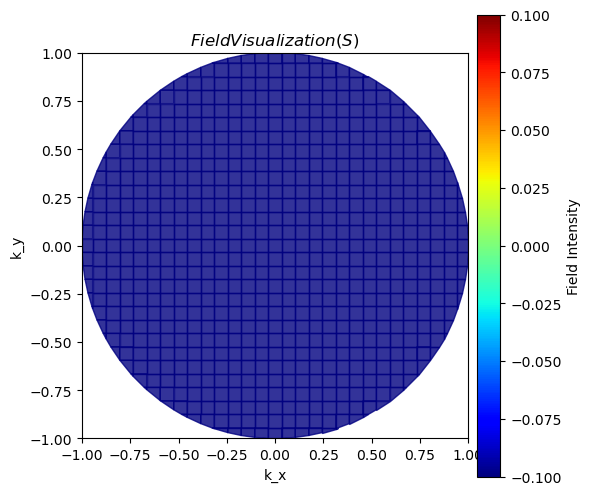

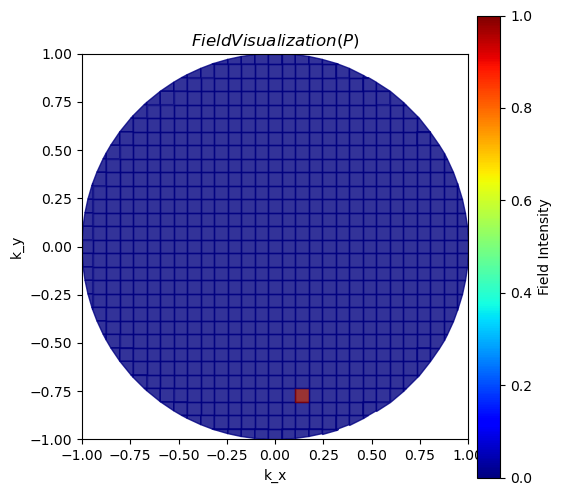

/tmp/ipykernel_125864/1727931790.py:25: RuntimeWarning: invalid value encountered in divide
  e_phi /= mod_kappa[..., xp.newaxis]
/tmp/ipykernel_125864/1727931790.py:41: RuntimeWarning: invalid value encountered in divide
  e_theta /= xp.sqrt(


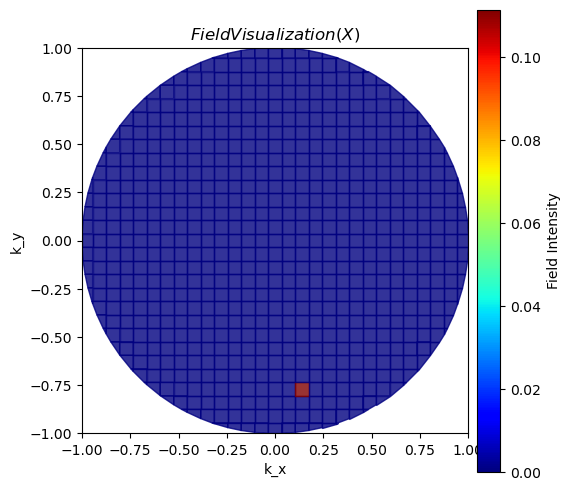

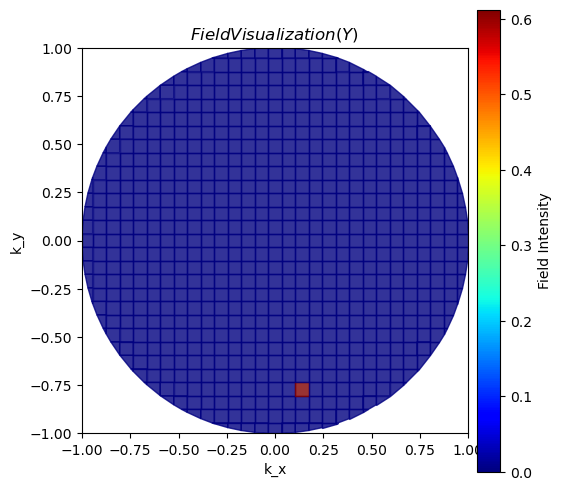

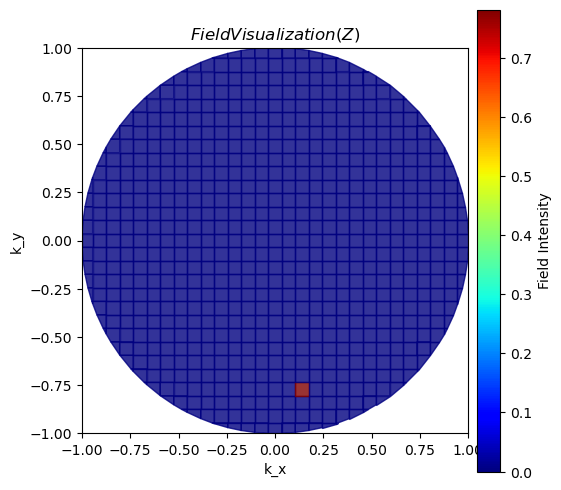

In [4]:
list_inc_modes = [-302, 0, 302]
E = generate_field_sp(
    list_inc_modes, my_grid.num_propagating, incident_pol=np.array([0, 1])
)  # <--- [s,p]
Es_inc = E[
    :, 0::2
]  # ,--- first index is the mode number (len(list_inc_modes),num_propagating)
Ep_inc = E[:, 1::2]
# plot s and p parts for incident mode -302
inc_mode = -302
plot_field_on_grid(
    my_grid, np.abs(Es_inc[list_inc_modes.index(inc_mode) ** 2, :]), type="S"
)
plot_field_on_grid(
    my_grid, np.abs(Ep_inc[list_inc_modes.index(inc_mode) ** 2, :]), type="P"
)
# Convert to kx,ky,kz components
Ekx, Eky, Ekz = from_sp_2_kxkykz(my_grid, Es_inc, Ep_inc)
# plot kx,ky,kz parts for incident mode -302
plot_field_on_grid(
    my_grid, np.abs(Ekx[list_inc_modes.index(inc_mode) ** 2, :]), type="X"
)
plot_field_on_grid(
    my_grid, np.abs(Eky[list_inc_modes.index(inc_mode) ** 2, :]), type="Y"
)
plot_field_on_grid(
    my_grid, np.abs(Ekz[list_inc_modes.index(inc_mode) ** 2, :]), type="Z"
)

/tmp/ipykernel_125864/1727931790.py:25: RuntimeWarning: invalid value encountered in divide
  e_phi /= mod_kappa[..., xp.newaxis]
/tmp/ipykernel_125864/1727931790.py:41: RuntimeWarning: invalid value encountered in divide
  e_theta /= xp.sqrt(


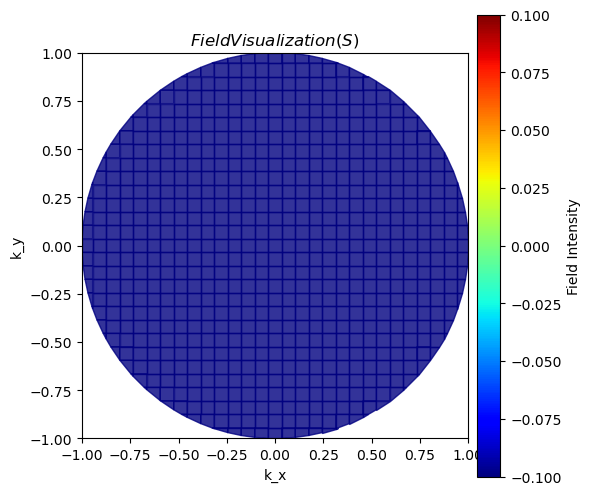

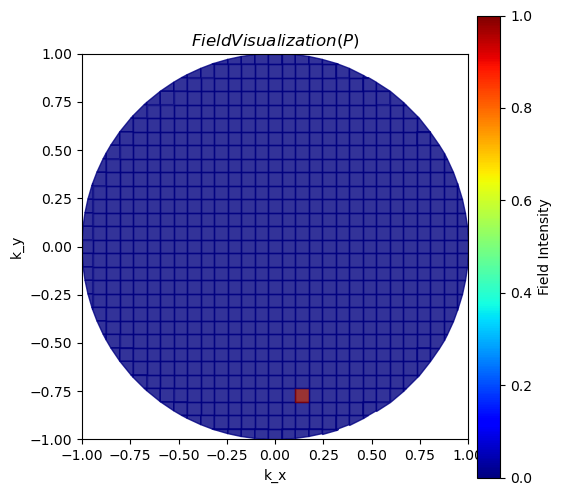

In [5]:
# To check if we get back the same Es, Ep for Ex,Ey,Ez
Es2,Ep2 = from_kxkykz_2_sp(my_grid,Ekx,Eky,Ekz)
# plot again
plot_field_on_grid(my_grid,np.abs(Es2[list_inc_modes.index(inc_mode)**2,:]),type="S")
plot_field_on_grid(my_grid,np.abs(Ep2[list_inc_modes.index(inc_mode)**2,:]),type="P")

In [6]:
# generate icident field for choice of mode indices
list_inc_modes = [302, 0, -302]
E = generate_field_sp(
    list_inc_modes, my_grid.num_propagating
)  # <--- generate field using s and p polarisation
# Separate out s and p polairsed components
Es_inc = E[:, 0::2]
Ep_inc = E[:, 1::2]
# Intenisty of incide field
I_inc = np.abs(Es_inc) ** 2 + np.abs(Ep_inc) ** 2
# Scattered field calculation
S = pm.S[0]
t = matrix_utils.get_block(S, "t")
sca = (t @ E.T).T
# Separate out s and p polairsed components of scattered field
Es_sca = sca[:, 0::2]
Ep_sca = sca[:, 1::2]
# Intensity of scattered field
I_sca = np.abs(Es_sca) ** 2 + np.abs(Ep_sca) ** 2

In [7]:
# If you want to average over S matrices
I_sca_list = []
for i in range(len(pm.S)):
    S = pm.S[i]
    t = matrix_utils.get_block(S, "t")
    sca = (t @ E.T).T
    Es_sca = sca[:, 0::2]
    Ep_sca = sca[:, 1::2]
    I_sca_list.append(np.abs(Es_sca)**2 + np.abs(Ep_sca)**2)

# Average
I_sca_avg = np.mean(I_sca_list, axis=0)

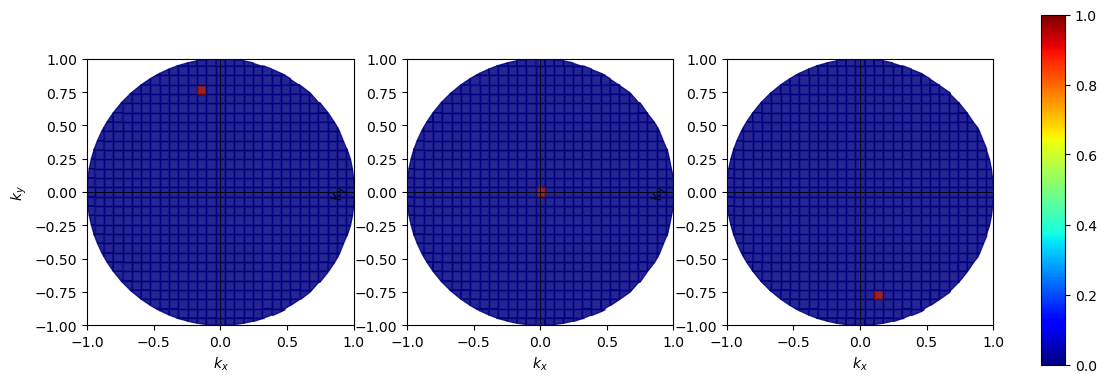

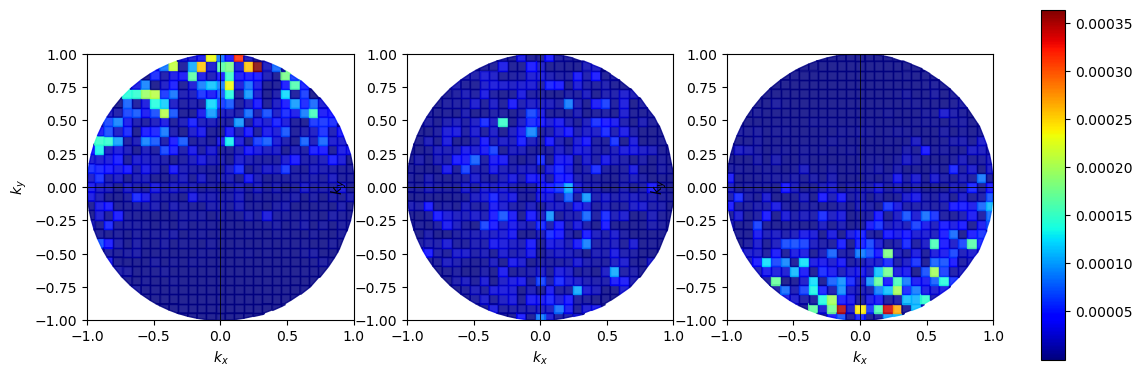

In [8]:
# plot incident fields
multi_plot_grid(my_grid,I_inc)
# plot scattered fields
multi_plot_grid(my_grid,I_sca)

/tmp/ipykernel_125864/1727931790.py:25: RuntimeWarning: invalid value encountered in divide
  e_phi /= mod_kappa[..., xp.newaxis]
/tmp/ipykernel_125864/1727931790.py:41: RuntimeWarning: invalid value encountered in divide
  e_theta /= xp.sqrt(


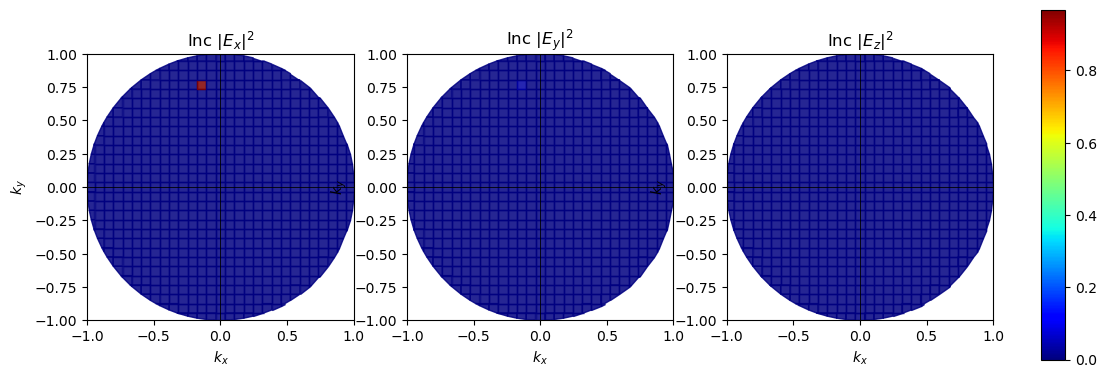

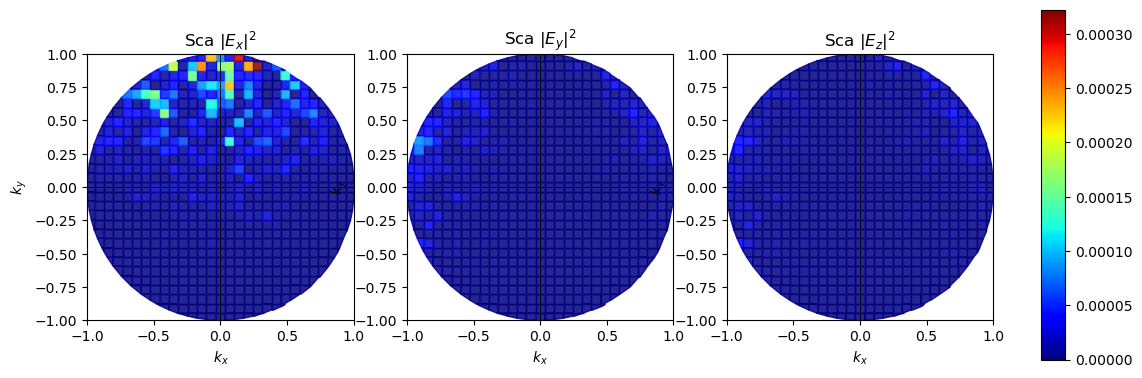

In [9]:
Ekx, Eky, Ekz = from_sp_2_kxkykz(
    my_grid, Es_inc, Ep_inc
)  # <--- contains the kx,ky,kz components for all incident modes
inc_mode = 302  # Choose a mode from the list of incident modes
E_inc = np.vstack(
    [
        np.abs(Ekx[list_inc_modes.index(inc_mode), :]) ** 2,
        np.abs(Eky[list_inc_modes.index(inc_mode), :]) ** 2,
        np.abs(Ekz[list_inc_modes.index(inc_mode), :]) ** 2,
    ]
)  # ,--- intensities of incident field components
multi_plot_grid(
    my_grid, E_inc, titles=["Inc $|E_x|^2$", "Inc $|E_y|^2$", "Inc $|E_z|^2$"]
)
# scatter field
S = pm.S[0]
t = matrix_utils.get_block(S, "t")
sca = t @ E[list_inc_modes.index(inc_mode), :]
Es_sca = sca[0::2]
Ep_sca = sca[1::2]
"""The incident field Ekx,Eky,Ekz have shape (number of non zero modes,num_propagating) In this example 
    we are checking 3 modes so (3,number of propagating). We can not scatter them togerther so we choose one mode at a time"""
Ekx_sca, Eky_sca, Ekz_sca = from_sp_2_kxkykz(
    my_grid, Es_sca[np.newaxis, :], Ep_sca[np.newaxis, :]
)  # <--- contains the kx,ky,kz components for scattered field

E_sca = np.vstack(
    [np.abs(Ekx_sca) ** 2, np.abs(Eky_sca) ** 2, np.abs(Ekz_sca) ** 2]
)  # ,--- intensities of scattered field components
multi_plot_grid(
    my_grid, E_sca, titles=["Sca $|E_x|^2$", "Sca $|E_y|^2$", "Sca $|E_z|^2$"]
)

100%|██████████| 697/697 [00:03<00:00, 209.15it/s]


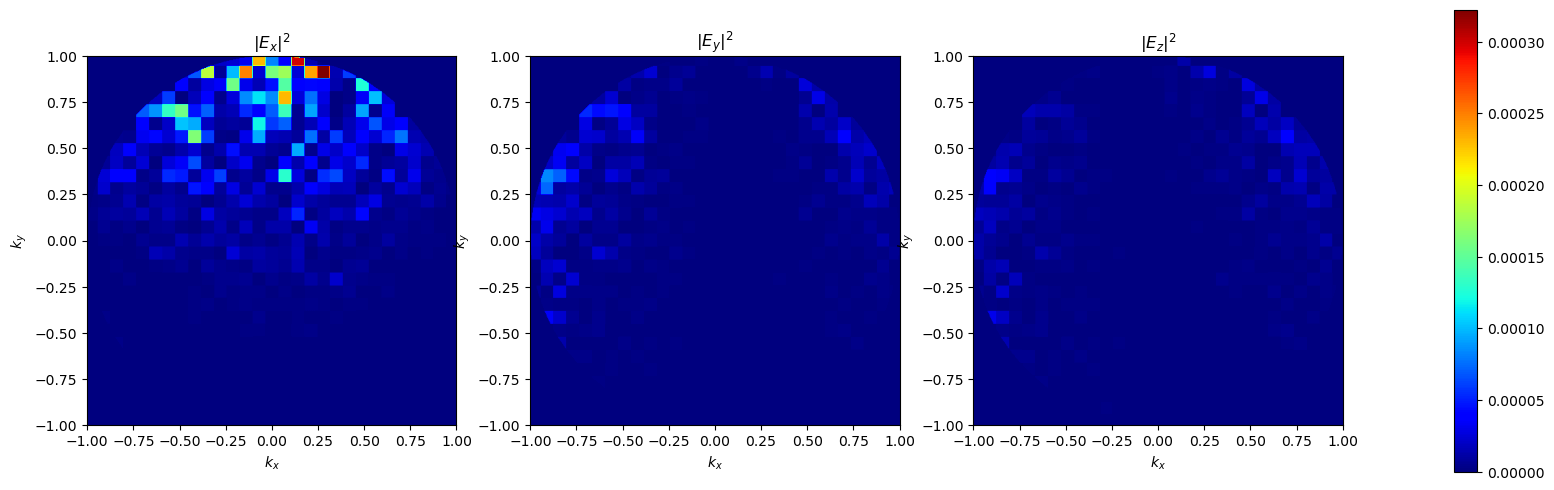

In [10]:
# converts field componenets to a 2D meshgrid. This helps to change to real space if necessary
 
sca_index = 0 #will always wbe zero as long as we scatter one mode at a time
Ekx_mesh, Eky_mesh, Ekz_mesh = grid_2_mesh(
    my_grid, Ekx_sca[sca_index, :], Eky_sca[sca_index, :], Ekz_sca[sca_index, :]
)  # <---field component entries shouls be a list of values of shape (num_propagating,)


fig, axs = plt.subplots(1, 3, figsize=(18, 6))

fields = [np.abs(Ekx_mesh) ** 2, np.abs(Eky_mesh) ** 2, np.abs(Ekz_mesh) ** 2]
titles = ["$|E_x|^2$", "$|E_y|^2$", "$|E_z|^2$"]

# Find common color limits
vmin = min(field.min() for field in fields)
vmax = max(field.max() for field in fields)

for i, ax in enumerate(axs):
    im = ax.imshow(
        fields[i],
        extent=[-1, 1, -1, 1],
        cmap="jet",
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(titles[i])
    ax.set_xlabel("$k_x$")
    ax.set_ylabel("$k_y$")

# Add a single colorbar for all plots
fig.colorbar(im, ax=axs, orientation="vertical", fraction=0.02, pad=0.08)
# plt.tight_layout()
plt.show()

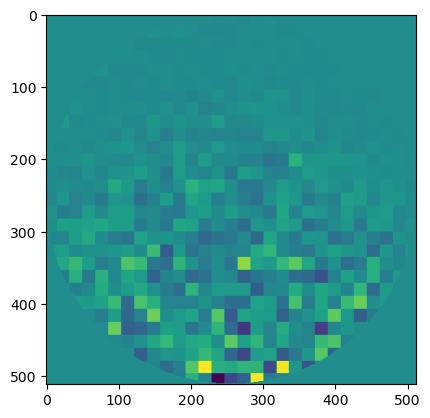

In [15]:
plt.imshow(Ekx_mesh.real)

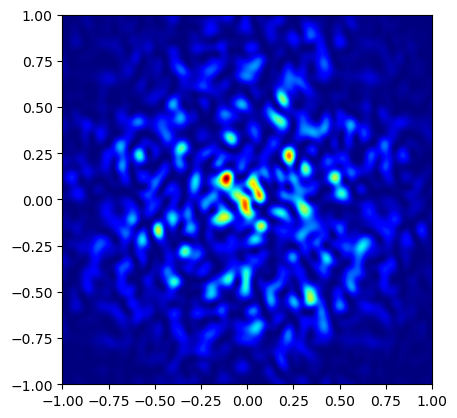

In [11]:
# Convert to real space using CZT
Ex = czt2(Ekx_mesh,mode="IFT")
plt.imshow(np.abs(Ex)**2, extent=(-1,1,-1,1), cmap="jet",origin="lower")